<a href="https://colab.research.google.com/github/gauravjha201/Information_retrieval_practice/blob/main/IR_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


In [27]:
documents = [
    "information retrieval system",
    "retrieval models and ranking",
    "machine learning algorithms",
    "clustering and classification",
    "search engines and retrieval",
    "deep learning for NLP"
]

doc_ids = ["D1", "D2", "D3", "D4", "D5", "D6"]

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

In [28]:
# 3. Cosine Similarity Matrix
similarity_matrix = cosine_similarity(X)

print("\nCosine Similarity Matrix:\n")
for i in range(len(documents)):
    for j in range(len(documents)):
        print(f"{similarity_matrix[i][j]:.2f}", end=" ")
    print()


Cosine Similarity Matrix:

1.00 0.25 0.00 0.00 0.25 0.00 
0.25 1.00 0.00 0.00 0.19 0.00 
0.00 0.00 1.00 0.00 0.00 0.25 
0.00 0.00 0.00 1.00 0.00 0.00 
0.25 0.19 0.00 0.00 1.00 0.00 
0.00 0.00 0.25 0.00 0.00 1.00 


In [29]:
# 4. K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
k_labels = kmeans.fit_predict(X)

print("\nK-Means Clustering Result:")
for i in range(len(documents)):
    print(doc_ids[i], "-> Cluster", k_labels[i])


K-Means Clustering Result:
D1 -> Cluster 1
D2 -> Cluster 1
D3 -> Cluster 0
D4 -> Cluster 1
D5 -> Cluster 1
D6 -> Cluster 0


In [30]:
# 5. Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=2)
h_labels = hc.fit_predict(X.toarray())

print("\nHierarchical Clustering Result:")
for i in range(len(documents)):
    print(doc_ids[i], "-> Cluster", h_labels[i])


Hierarchical Clustering Result:
D1 -> Cluster 1
D2 -> Cluster 1
D3 -> Cluster 0
D4 -> Cluster 0
D5 -> Cluster 1
D6 -> Cluster 0


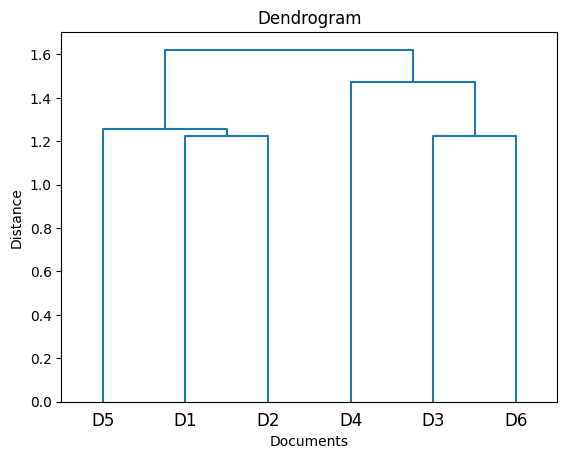

In [31]:
# 6. Dendrogram
linked = linkage(X.toarray(), method='ward')

plt.figure()
dendrogram(linked, labels=doc_ids)
plt.title("Dendrogram")
plt.xlabel("Documents")
plt.ylabel("Distance")
plt.show()


In [32]:
# 7. Test Document
test_doc = ["retrieval search system"]
test_vec = vectorizer.transform(test_doc)

# K-Means Prediction
k_pred = kmeans.predict(test_vec)
print("\nTest Document (K-Means) -> Cluster:", k_pred[0])


Test Document (K-Means) -> Cluster: 1


In [33]:
# Cosine similarity for Hierarchical assignment
test_similarity = cosine_similarity(test_vec, X)

print("\nTest Document Similarity:")
for i in range(len(documents)):
    print(f"{doc_ids[i]}: {test_similarity[0][i]:.2f}")

# Assign cluster based on closest document
closest_doc = test_similarity.argmax()
h_pred = h_labels[closest_doc]

print("\nTest Document (Hierarchical) -> Cluster:", h_pred)


Test Document Similarity:
D1: 0.32
D2: 0.25
D3: 0.00
D4: 0.00
D5: 0.77
D6: 0.00

Test Document (Hierarchical) -> Cluster: 1
